# fig1_new_region - Part 3/8\n\n自动拆分版本（按步骤执行）。\n包含统一 bootstrap 和共享模块导入。\n

In [ ]:
# AUTO_BOOTSTRAP_V2
from pathlib import Path
import sys
import os
import builtins
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "projects").exists():
    cur = Path.cwd().resolve()
    for p in [cur] + list(cur.parents):
        if (p / "projects").exists():
            ROOT = p
            break

NB_PATH = Path.cwd()
if "clone_motif" in str(NB_PATH):
    PROJECT_DIR = ROOT / "projects" / "clone_motif"
else:
    PROJECT_DIR = ROOT / "projects" / "our_multiregion_motif"

DATA_RAW = PROJECT_DIR / "data" / "raw"
DATA_PROCESSED = PROJECT_DIR / "data" / "processed"
OUT_FIG = PROJECT_DIR / "outputs" / "figures"
OUT_TABLE = PROJECT_DIR / "outputs" / "tables"
OUT_ARCH = PROJECT_DIR / "outputs" / "archives"

for d in [DATA_PROCESSED, OUT_FIG, OUT_TABLE, OUT_ARCH]:
    d.mkdir(parents=True, exist_ok=True)

SHARED_SRC = ROOT / "projects" / "shared" / "src"
if str(SHARED_SRC) not in sys.path:
    sys.path.append(str(SHARED_SRC))

from motif_common import combination, indices_for_region, union_indices_for_regions, p_to_star, format_p_decimal_3sig, sort_by_order, truncate_colormap

READ_EXT = {".csv", ".json", ".npy", ".pkl", ".xlsx"}
FIG_EXT = {".svg", ".png", ".pdf"}
TABLE_EXT = {".csv", ".xlsx"}


def _as_path(x):
    return Path(x) if isinstance(x, (str, os.PathLike)) else x


def resolve_read_path(path):
    p = _as_path(path)
    if not isinstance(p, Path):
        return path
    if p.is_absolute() or p.exists():
        return str(p)
    if p.suffix.lower() in READ_EXT:
        for c in [DATA_RAW / p.name, ROOT / p.name]:
            if c.exists():
                return str(c)
    return str(p)


def resolve_write_path(path):
    p = _as_path(path)
    if not isinstance(p, Path):
        return path
    if p.is_absolute():
        p.parent.mkdir(parents=True, exist_ok=True)
        return str(p)
    ext = p.suffix.lower()
    if ext in FIG_EXT:
        out = OUT_FIG / p.name
    elif ext in TABLE_EXT:
        out = OUT_TABLE / p.name
    elif ext == ".zip":
        out = OUT_ARCH / p.name
    elif ext == ".npy":
        out = DATA_PROCESSED / p.name
    else:
        out = PROJECT_DIR / p
    out.parent.mkdir(parents=True, exist_ok=True)
    return str(out)

if not hasattr(builtins, "_orig_open_codex"):
    builtins._orig_open_codex = builtins.open


def _open_patch(file, mode="r", *args, **kwargs):
    if isinstance(file, (str, os.PathLike)):
        if any(m in mode for m in ["r", "a"]):
            file = resolve_read_path(file)
        if any(m in mode for m in ["w", "a", "x"]):
            file = resolve_write_path(file)
    return builtins._orig_open_codex(file, mode, *args, **kwargs)


builtins.open = _open_patch

if not hasattr(np, "_orig_load_codex"):
    np._orig_load_codex = np.load
np.load = lambda file, *a, **k: np._orig_load_codex(resolve_read_path(file), *a, **k)

if not hasattr(np, "_orig_save_codex"):
    np._orig_save_codex = np.save
np.save = lambda file, arr, *a, **k: np._orig_save_codex(resolve_write_path(file), arr, *a, **k)

if not hasattr(pd, "_orig_read_csv_codex"):
    pd._orig_read_csv_codex = pd.read_csv
pd.read_csv = lambda f, *a, **k: pd._orig_read_csv_codex(resolve_read_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)

if not hasattr(pd, "_orig_read_excel_codex"):
    pd._orig_read_excel_codex = pd.read_excel
pd.read_excel = lambda f, *a, **k: pd._orig_read_excel_codex(resolve_read_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)

if not hasattr(pd.DataFrame, "_orig_to_csv_codex"):
    pd.DataFrame._orig_to_csv_codex = pd.DataFrame.to_csv


def _to_csv_patch(self, path_or_buf=None, *args, **kwargs):
    if isinstance(path_or_buf, (str, os.PathLike)):
        path_or_buf = resolve_write_path(path_or_buf)
    return pd.DataFrame._orig_to_csv_codex(self, path_or_buf, *args, **kwargs)


pd.DataFrame.to_csv = _to_csv_patch

if not hasattr(pd.DataFrame, "_orig_to_excel_codex"):
    pd.DataFrame._orig_to_excel_codex = pd.DataFrame.to_excel


def _to_excel_patch(self, excel_writer, *args, **kwargs):
    if isinstance(excel_writer, (str, os.PathLike)):
        excel_writer = resolve_write_path(excel_writer)
    return pd.DataFrame._orig_to_excel_codex(self, excel_writer, *args, **kwargs)


pd.DataFrame.to_excel = _to_excel_patch

try:
    import matplotlib.pyplot as plt
    if not hasattr(plt, "_orig_savefig_codex"):
        plt._orig_savefig_codex = plt.savefig
    plt.savefig = lambda f, *a, **k: plt._orig_savefig_codex(resolve_write_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)
except Exception:
    pass

print(f"[bootstrap] project={PROJECT_DIR.name} data={DATA_RAW}")


In [42]:
print(er_motif)
print(er_motif_sd)

[8.56981259e+05 8.57013581e+05 1.71396090e+06 8.82529215e+04
 8.82123000e+04 8.81975400e+04 2.27113450e+03 2.27130050e+03
 2.26935650e+03 2.94195747e+04 4.54280550e+03 2.34197000e+02
 1.99600001e+00]
[2.63290410e+03 2.59977011e+03 5.08912454e+03 4.91813468e+02
 2.41706157e+03 2.40738555e+03 7.46387626e+01 7.31735634e+01
 1.38139906e+02 2.11480186e+02 1.32996503e+02 1.95916336e+01
 1.43073671e+00]


In [43]:
print(er_motif_clone)
print(er_motif_sd_clone)

[1.03804365e+04 1.03783470e+04 2.07513875e+04 1.03064400e+03
 1.03208700e+03 1.03147700e+03 2.58265000e+01 2.56390000e+01
 2.56820000e+01 3.43604001e+02 5.14070000e+01 2.59600000e+00
 1.90000000e-02]
[1.61422401e+02 1.58848355e+02 2.86287353e+02 3.73461729e+01
 1.30283861e+02 1.27888581e+02 5.80605312e+00 5.84223800e+00
 8.29055141e+00 1.98114985e+01 9.51870022e+00 1.69888997e+00
 1.40174264e-01]


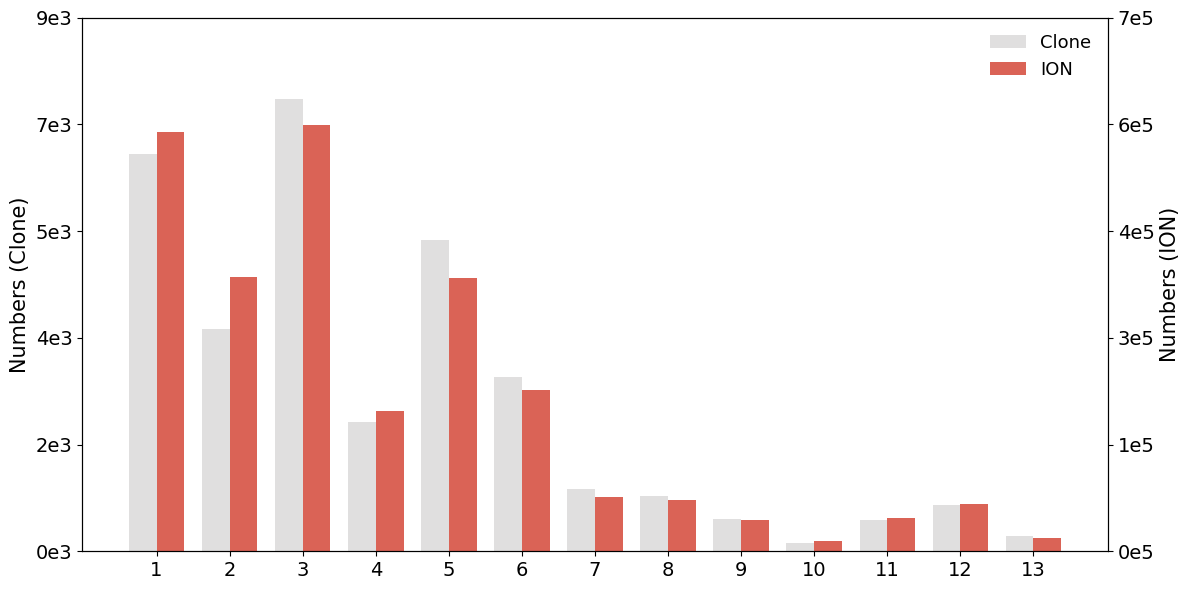

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ========= 你已经有这4个量 =========
# real_motif        : ION 的 13维真实 motif 计数
# real_motif_clone  : Clone 的 13维真实 motif 计数
# frequency         : ION 归一化频率（real_motif / sum）
# frequency_clone   : Clone 归一化频率（real_motif_clone / sum）
# =================================

# ---- 频率（柱高用这个）----
f_ion   = np.asarray(frequency, float).ravel()
f_clone = np.asarray(frequency_clone, float).ravel()
if f_ion.shape[0] == 14:   f_ion = f_ion[1:]
if f_clone.shape[0] == 14: f_clone = f_clone[1:]
assert f_ion.shape[0] == 13 and f_clone.shape[0] == 13, (f_ion.shape, f_clone.shape)

# ---- 总数（左右坐标都乘这个）----
total_ion   = float(np.asarray(real_motif, float).sum())
total_clone = float(np.asarray(real_motif_clone, float).sum())

# ---- 配色（天蓝/粉红相关）----
colors = plt.cm.coolwarm(np.linspace(0.5, 0.9, 2))
c1, c2 = colors[0], colors[-1]   # 天蓝 / 玫粉


x = np.arange(13)
w = 0.38

fig, axL = plt.subplots(figsize=(12, 6))

# 柱子高度仍然是“归一化频率”
axL.bar(x - w/2, f_clone, width=w, label="Clone", color=c1, alpha=0.90)
axL.bar(x + w/2, f_ion,   width=w, label="ION",   color=c2,   alpha=0.90)

# x/y 字体大一点
axL.set_xticks(x)
axL.set_xticklabels([f"{i}" for i in range(1, 14)], fontsize=14)
axL.tick_params(axis="y", labelsize=14)

# y范围（频率轴），右轴会同步显示成“计数”的刻度文字
ymax = float(np.nanmax([np.nanmax(f_clone), np.nanmax(f_ion)]))
axL.set_ylim(0, ymax * 1.18)

# 让左右两侧刻度位置一致（频率刻度），只改“显示文字”
yt = np.linspace(0, axL.get_ylim()[1], 6)
axL.set_yticks(yt)

# 左轴：显示成 k（取整），单位 k
axL.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f"{int(np.rint(y * total_clone / 1e3))}e3")
)
axL.set_ylabel("Numbers (Clone)", fontsize=15)

# 右轴：显示成 100k（取整），单位 100k
axR = axL.twinx()
axR.set_ylim(axL.get_ylim())
axR.set_yticks(yt)
axR.tick_params(axis="y", labelsize=14)
axR.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f"{int(np.rint(y * total_ion / 1e5))}e5")
)
axR.set_ylabel("Numbers (ION)", fontsize=15)

# 不要标题
axL.legend(fontsize=13, frameon=False)
plt.tight_layout()
plt.savefig("motif_frequency_comparison_clone_ion.svg", bbox_inches='tight',  dpi=300, transparent=True)
plt.show()

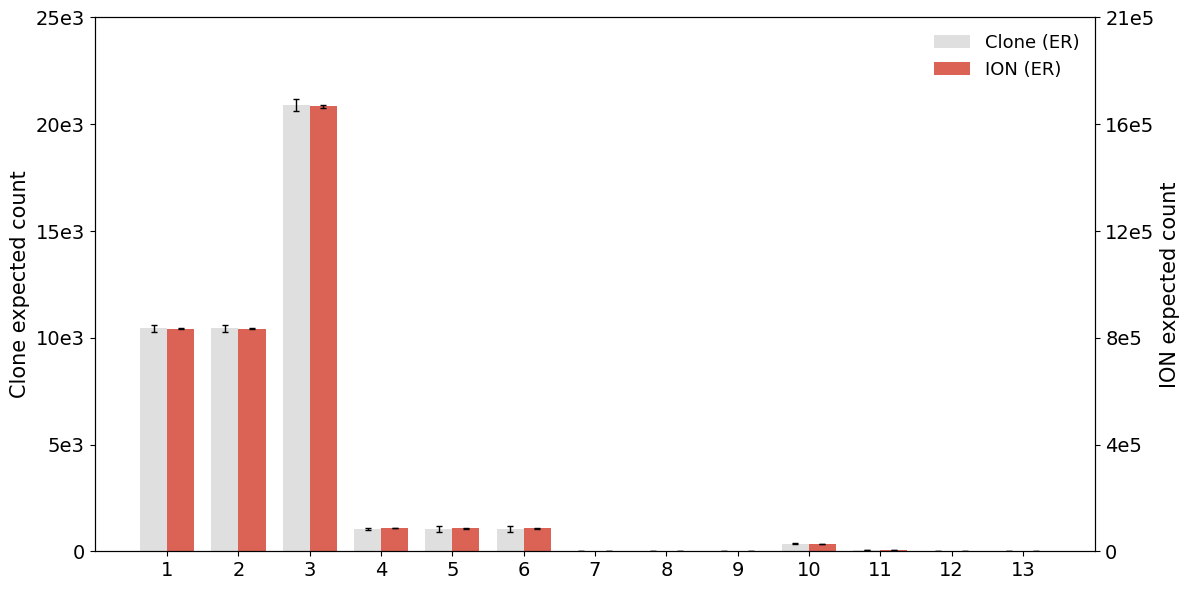

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# =======================
# 输入（你已给出）
# er_motif, er_motif_sd = ...  # ION: ER mean / ER sd
# er_motif_clone, er_motif_sd_clone = ...  # Clone: ER mean / ER sd
# =======================

mu_ion = np.asarray(er_motif, float).ravel()
sd_ion = np.asarray(er_motif_sd, float).ravel()
mu_cl  = np.asarray(er_motif_clone, float).ravel()
sd_cl  = np.asarray(er_motif_sd_clone, float).ravel()

# 兼容 14 维老版本
if mu_ion.size == 14: mu_ion, sd_ion = mu_ion[1:], sd_ion[1:]
if mu_cl.size  == 14: mu_cl,  sd_cl  = mu_cl[1:],  sd_cl  = mu_cl[1:], sd_cl[1:]
assert mu_ion.size == 13 and mu_cl.size == 13, (mu_ion.shape, mu_cl.shape)

# ---- 归一化频率（柱高）----
S_ion = float(np.sum(mu_ion))
S_cl  = float(np.sum(mu_cl))
f_ion = mu_ion / S_ion
f_cl  = mu_cl  / S_cl

# ---- 归一化后的误差（yerr）----
f_sd_ion = sd_ion / S_ion
f_sd_cl  = sd_cl  / S_cl

# ---- 配色（天蓝/粉红）----
c_clone = c1
c_ion   = c2

x = np.arange(13)
w = 0.38

fig, axL = plt.subplots(figsize=(12, 6))

# Clone（左）
axL.bar(x - w/2, f_cl, width=w, label="Clone (ER)", color=c_clone, alpha=0.90)
axL.errorbar(x - w/2, f_cl, yerr=f_sd_cl, fmt="none", ecolor="black",
             elinewidth=1.0, capsize=2, capthick=1.0)

# ION（右）
axL.bar(x + w/2, f_ion, width=w, label="ION (ER)", color=c_ion, alpha=0.90)
axL.errorbar(x + w/2, f_ion, yerr=f_sd_ion, fmt="none", ecolor="black",
             elinewidth=1.0, capsize=2, capthick=1.0)

# x 轴
axL.set_xticks(x)
axL.set_xticklabels([f"{i}" for i in range(1, 14)], fontsize=14)

# y 轴范围（频率轴），并为误差留余量
ymax = float(np.nanmax([np.nanmax(f_cl + f_sd_cl), np.nanmax(f_ion + f_sd_ion)]))
axL.set_ylim(0, ymax * 1.18 if ymax > 0 else 1.0)

# 统一刻度位置（频率），但左右显示“缩放后的自然计数”
yt = np.linspace(0, axL.get_ylim()[1], 6)
axL.set_yticks(yt)
axL.tick_params(axis="y", labelsize=14)

# ===== 关键：左 e3，右 e5（取整）=====
scale_L, exp_L = 1e3, "e3"
scale_R, exp_R = 1e5, "e5"

def fmt_scaled_count(y, S, scale, exp):
    cnt = y * S                       # 频率轴 -> 自然计数
    k = int(np.rint(cnt / scale))     # /1e3 或 /1e5 再取整
    return "0" if k == 0 else f"{k}{exp}"

axL.yaxis.set_major_formatter(FuncFormatter(lambda y, _: fmt_scaled_count(y, S_cl, scale_L, exp_L)))
axL.set_ylabel("Clone expected count", fontsize=15)

axR = axL.twinx()
axR.set_ylim(axL.get_ylim())
axR.set_yticks(yt)
axR.tick_params(axis="y", labelsize=14)
axR.yaxis.set_major_formatter(FuncFormatter(lambda y, _: fmt_scaled_count(y, S_ion, scale_R, exp_R)))
axR.set_ylabel("ION expected count", fontsize=15)

# 不要标题
axL.legend(fontsize=13, frameon=False)
plt.tight_layout()
plt.savefig("motif_frequency_er_comparison_clone_ion.svg", bbox_inches='tight',  dpi=300, transparent=True)
plt.show()

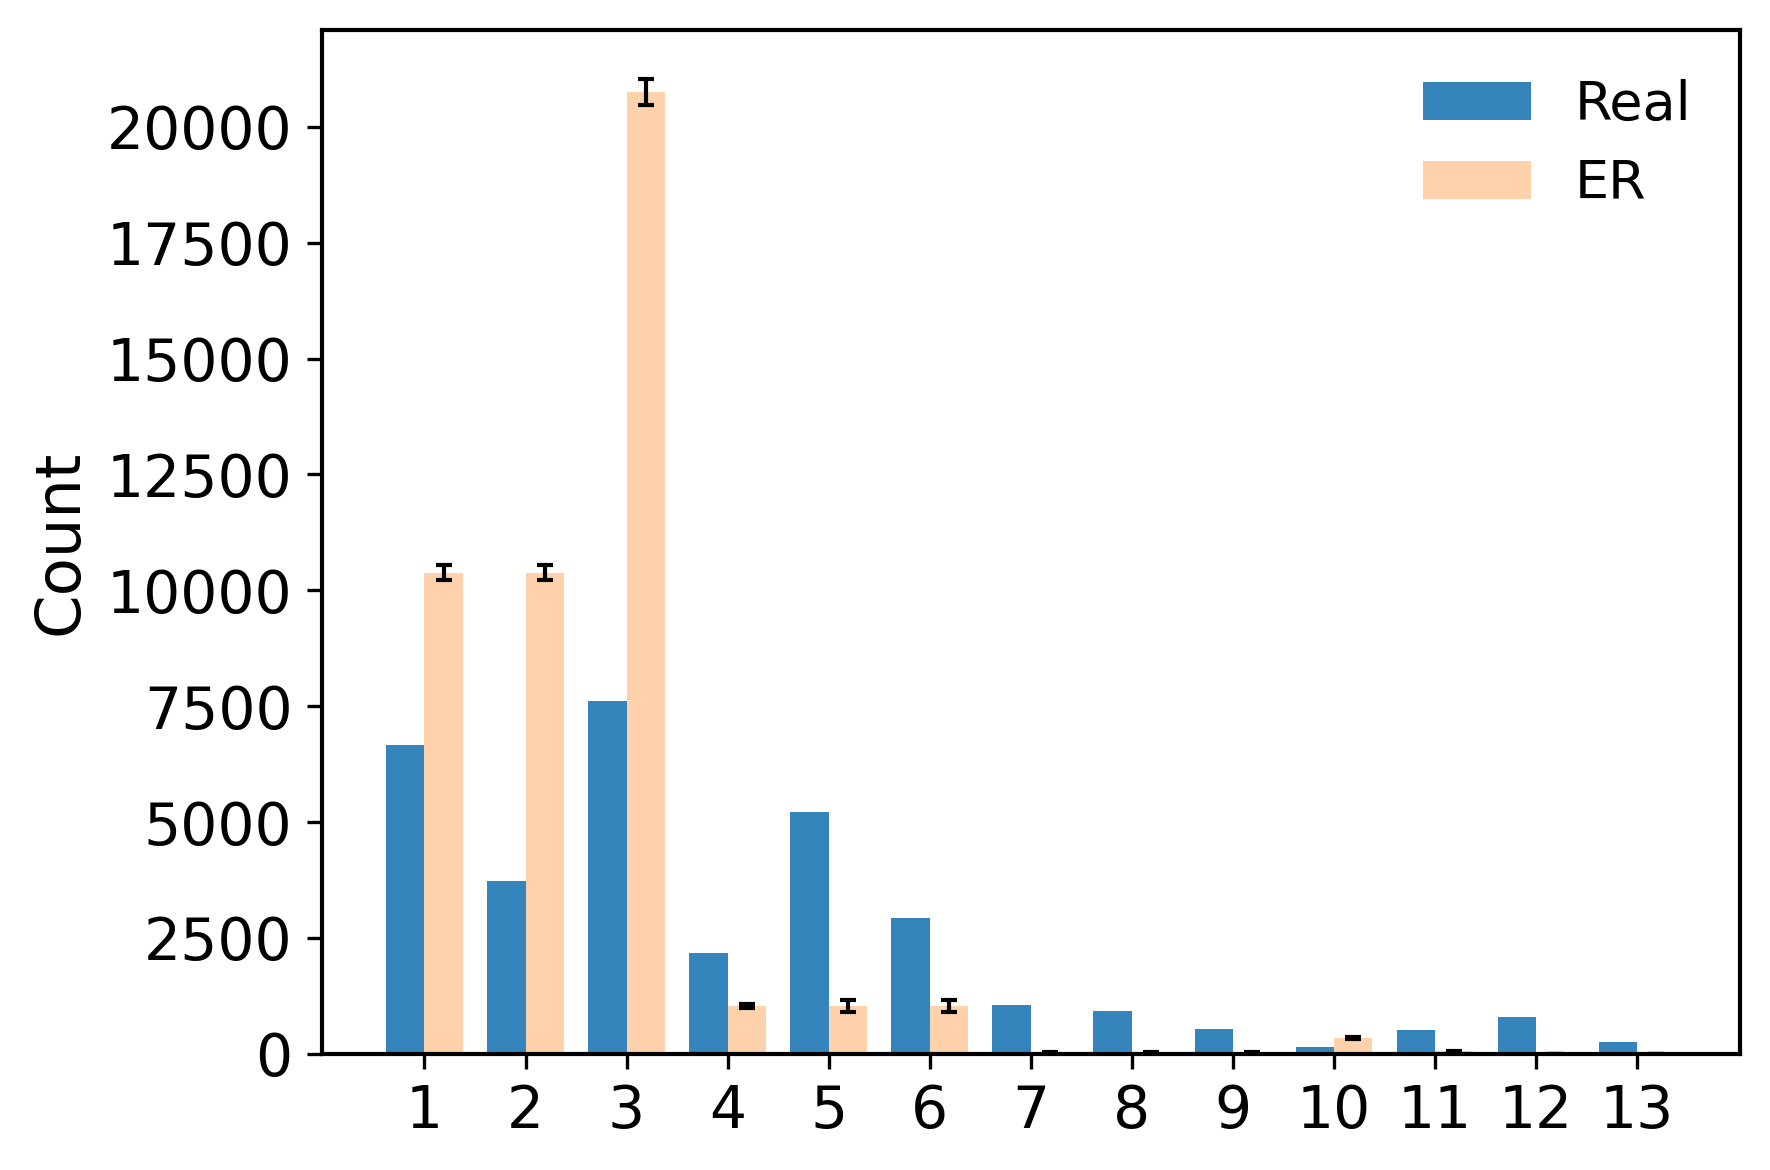

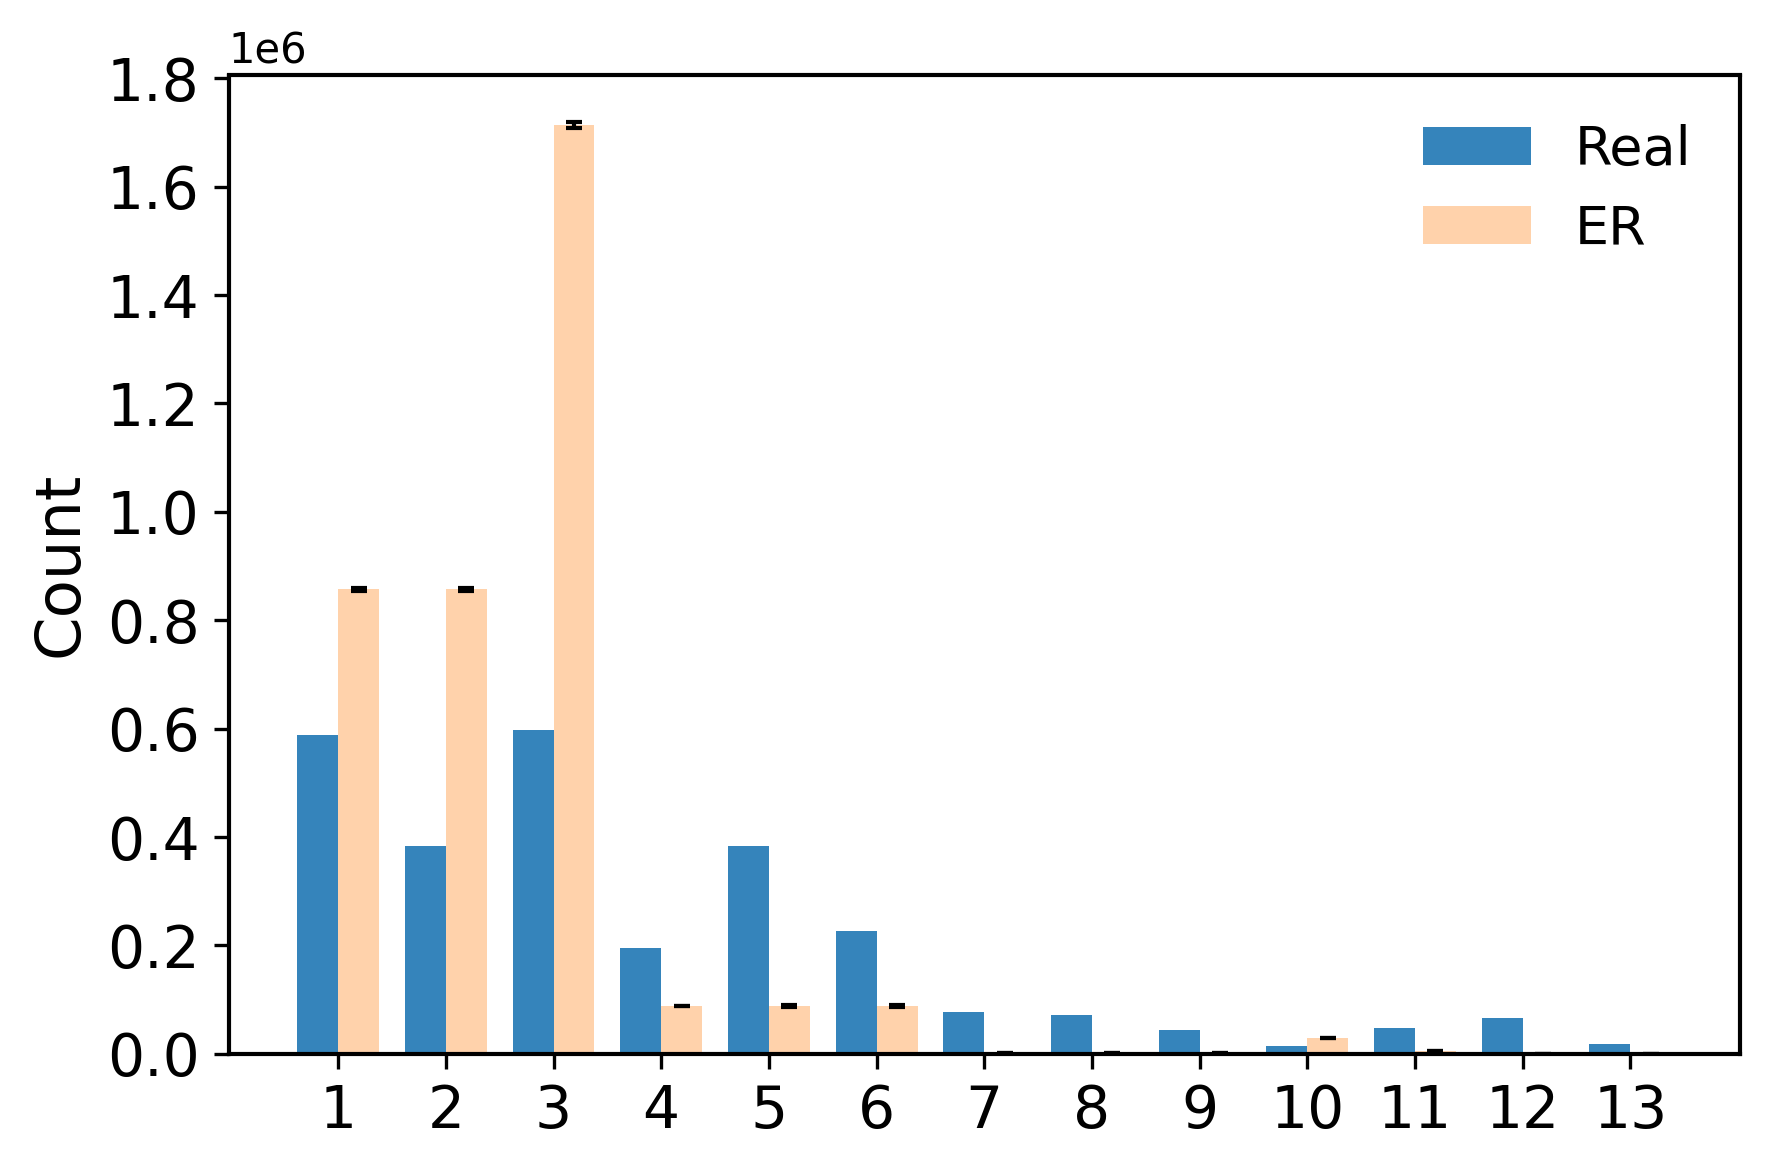

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 10,
    "axes.linewidth": 1.0,
})

def _as13(x):
    x = np.asarray(x, float).ravel()
    if x.size == 14:
        x = x[1:]
    assert x.size == 13, x.shape
    return x

def plot_counts_real_vs_er_linear(real_cnt, er_mu, er_sd, out_svg):
    real_cnt = _as13(real_cnt)
    er_mu = _as13(er_mu)
    er_sd = _as13(er_sd)

    x = np.arange(13)
    w = 0.38

    fig, ax = plt.subplots(figsize=(6, 4))

    # 默认配色：Real 用默认 C0；ER 用默认 C1（更透明）+ 误差线黑色
    ax.bar(x - w/2, real_cnt, width=w, alpha=0.90, label="Real")
    ax.bar(x + w/2, er_mu,    width=w, alpha=0.35, label="ER")
    ax.errorbar(x + w/2, er_mu, yerr=er_sd, fmt="none",
                ecolor="black", elinewidth=1.0, capsize=2, capthick=1.0)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{i}" for i in range(1, 14)], fontsize=14)
    ax.tick_params(axis="y", labelsize=14)
    ax.set_ylabel("Count", fontsize=15)

    # 只要整数刻度（线性轴）
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    ax.legend(fontsize=13, frameon=False)
    plt.tight_layout()
    plt.savefig(out_svg, bbox_inches="tight", dpi=300, transparent=True)
    plt.show()

# 图1：Clone（Real vs ER）
plot_counts_real_vs_er_linear(
    real_cnt=real_motif_clone,
    er_mu=er_motif_clone,
    er_sd=er_motif_sd_clone,
    out_svg="motif_count_clone_real_vs_er.svg"
)

# 图2：ION（Real vs ER）
plot_counts_real_vs_er_linear(
    real_cnt=real_motif,
    er_mu=er_motif,
    er_sd=er_motif_sd,
    out_svg="motif_count_ion_real_vs_er.svg"
)

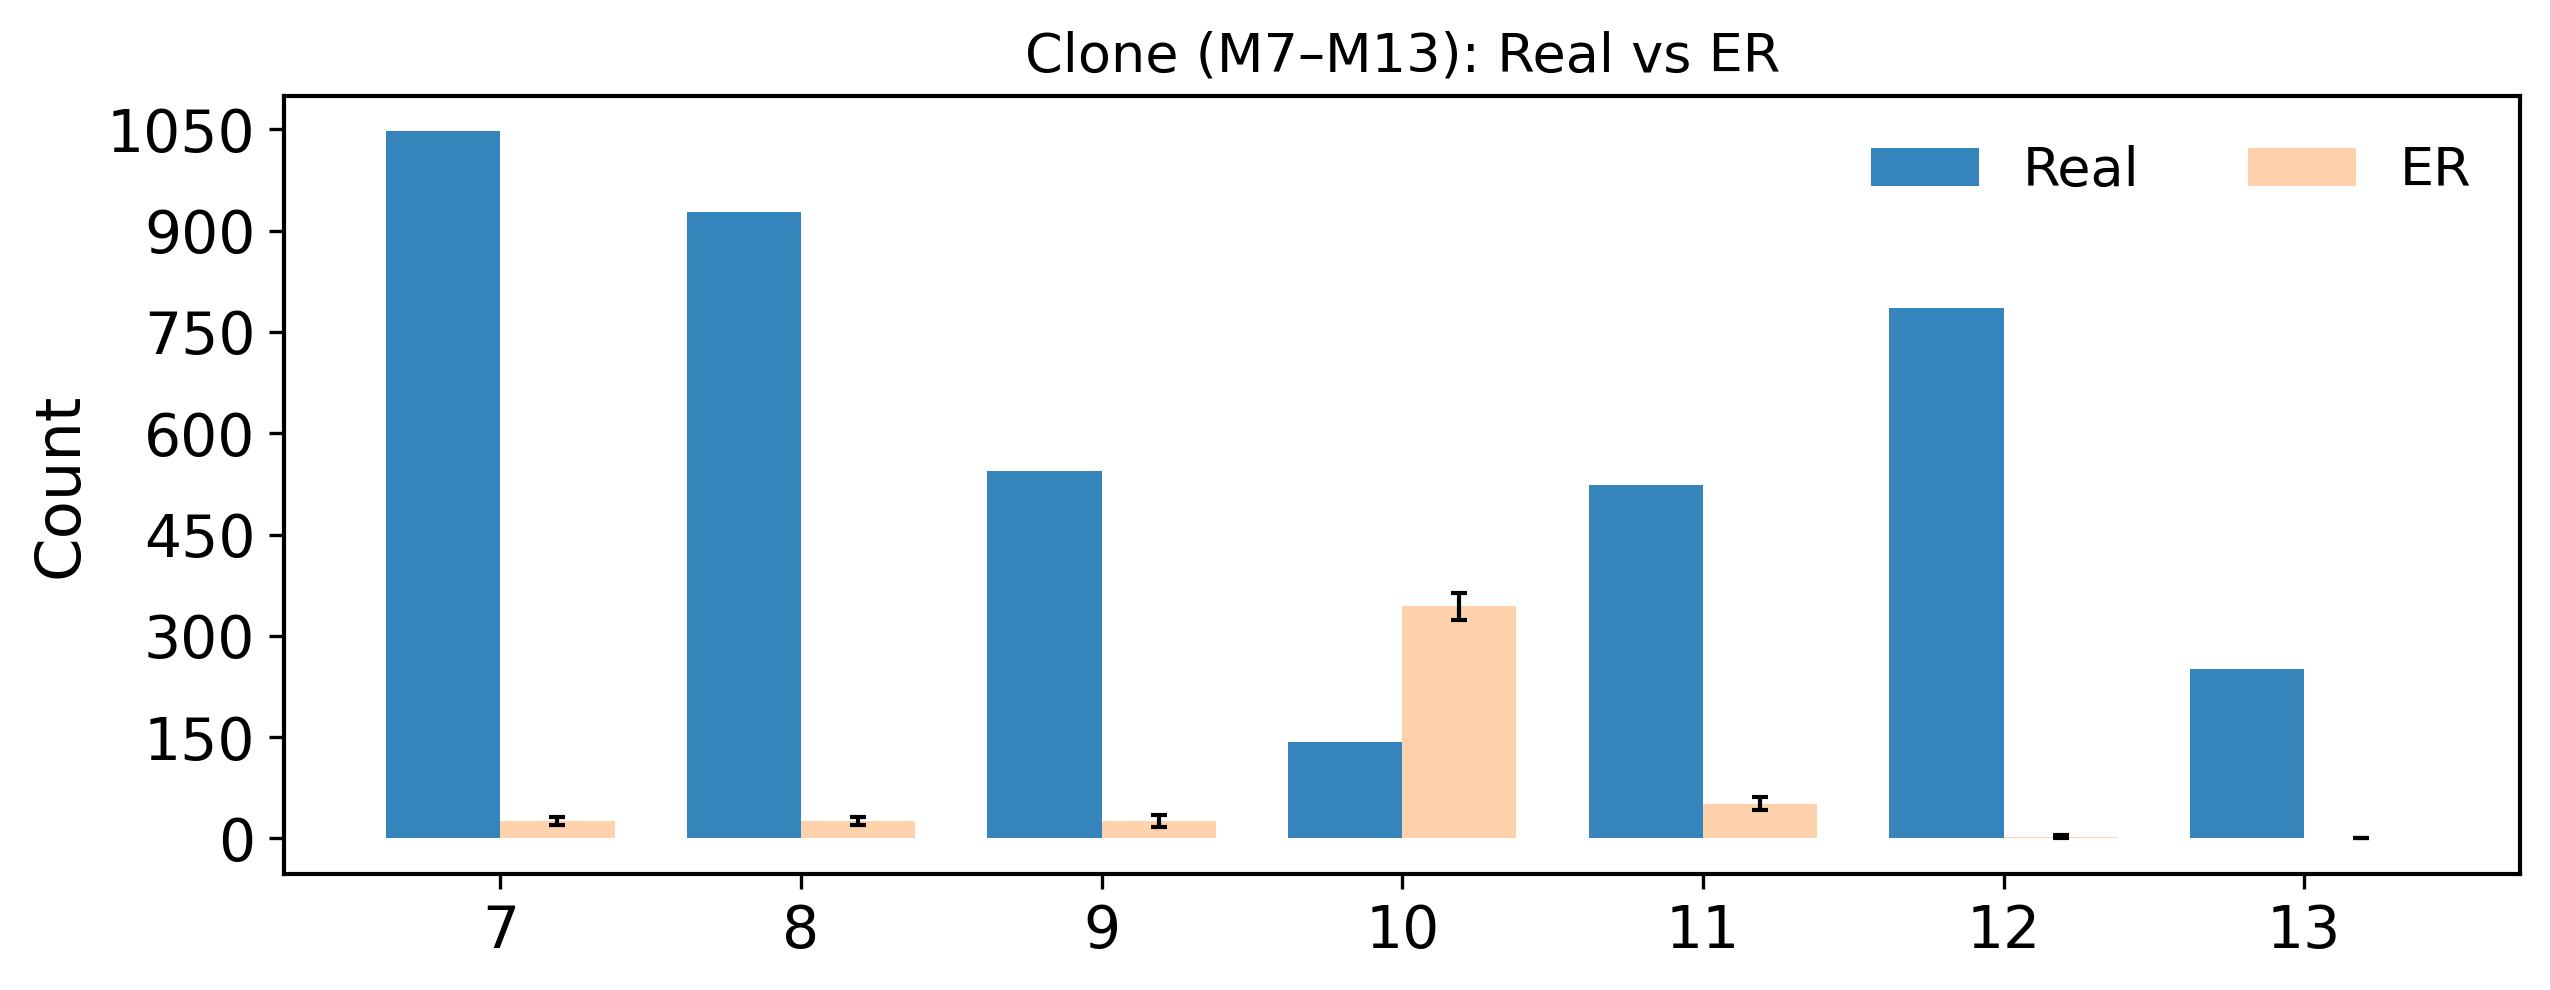

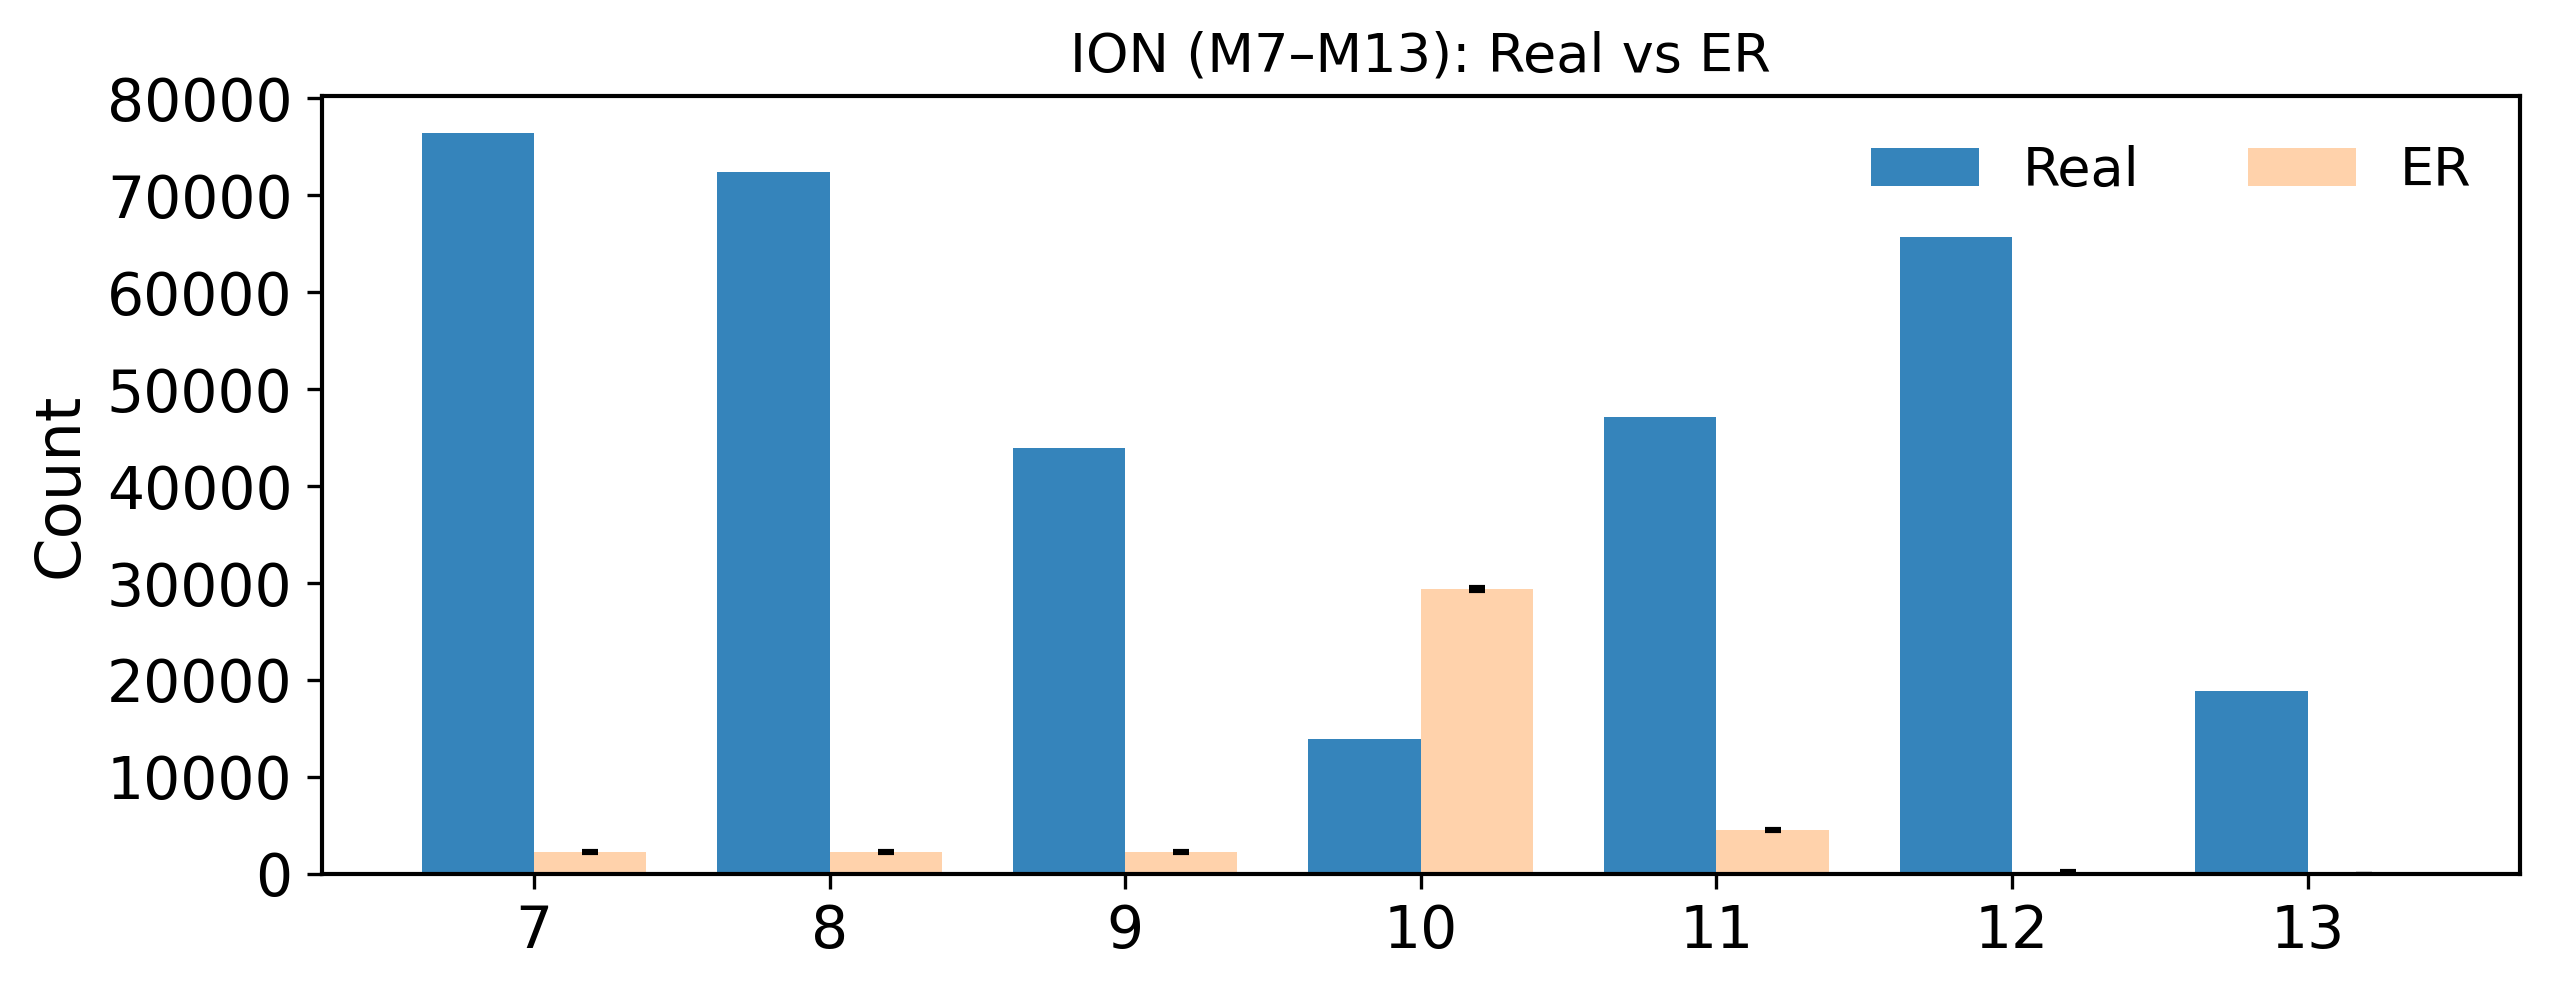

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 10,
    "axes.linewidth": 1.0,
})

def _as13(x):
    x = np.asarray(x, float).ravel()
    if x.size == 14:
        x = x[1:]
    assert x.size == 13, x.shape
    return x

# ===== 你已准备好的输入（保持不变）=====
# real_motif, real_motif_clone
# er_motif, er_motif_sd
# er_motif_clone, er_motif_sd_clone

real_ion   = _as13(real_motif)
real_clone = _as13(real_motif_clone)

mu_ion = _as13(er_motif)
sd_ion = _as13(er_motif_sd)

mu_cl = _as13(er_motif_clone)
sd_cl = _as13(er_motif_sd_clone)

motifs = list(range(7, 14))               # 7–13
idx = np.array([m - 1 for m in motifs])   # 0-based

def plot_one(title, real_cnt, mu, sd, out_svg):
    r = real_cnt[idx]
    m = mu[idx]
    s = sd[idx]

    x = np.arange(len(motifs))
    w = 0.38

    fig, ax = plt.subplots(figsize=(8.6, 3.4))

    # 默认配色：Real=C0；ER=C1（更透明）+ 黑色误差线
    ax.bar(x - w/2, r, width=w, alpha=0.90, label="Real")
    ax.bar(x + w/2, m, width=w, alpha=0.35, label="ER")
    ax.errorbar(x + w/2, m, yerr=s, fmt="none",
                ecolor="black", elinewidth=1.0, capsize=2, capthick=1.0)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{mm}" for mm in motifs], fontsize=14)
    ax.tick_params(axis="y", labelsize=14)

    # 只要整数刻度
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    ax.set_ylabel("Count", fontsize=15)
    ax.set_title(title, fontsize=13)

    # 标记 12/13 的 ER 均值±标准差（标在误差线上方）
    # for motif_id in [12, 13]:
    #     j = motifs.index(motif_id)
    #     mu_j = float(m[j])
    #     sd_j = float(s[j])
    #     txt = f"{np.rint(mu_j)}±{(np.rint(sd_j))}"
    #     ax.text(j + w/2, mu_j + sd_j, txt, ha="center", va="bottom", fontsize=11, color="black")

    ax.legend(frameon=False, ncol=2, fontsize=13)
    plt.tight_layout()
    plt.savefig(out_svg, bbox_inches="tight", dpi=300, transparent=True)
    plt.show()

# ===== 两张图：Clone / ION =====
plot_one("Clone (M7–M13): Real vs ER", real_clone, mu_cl, sd_cl,
         "Clone_real_vs_ER_M7-13.svg")

plot_one("ION (M7–M13): Real vs ER", real_ion, mu_ion, sd_ion,
         "ION_real_vs_ER_M7-13.svg")